# 1. Assignment Overview

Cell này làm gì?

Notebook này tiếp tục bài toán A03 Housing Price: dùng đặc trưng property để dự đoán giá nhà liên tục. A04 dùng King County House Sales trong `datasets/housing_price/a04`, tập trung vào deep learning regression trên dữ liệu tabular và so sánh cẩn thận với A03.


In [1]:
from pathlib import Path
import json
import pandas as pd

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in [start.resolve(), *start.resolve().parents]:
        if (path / "datasets" / "housing_price" / "a04").exists() and (path / "pipeline").exists():
            return path
    raise FileNotFoundError("Cannot locate project root from current working directory.")

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "datasets" / "housing_price" / "a04"
A03_NOTEBOOK = PROJECT_ROOT / "pipeline" / "house_price_pipeline.ipynb"
A03_METADATA_PATH = PROJECT_ROOT / "pipeline" / "house_price" / "metadata.json"
A03_COMPARISON_PATH = PROJECT_ROOT / "pipeline" / "house_price" / "final_comparison.csv"
A04_METADATA_PATH = DATA_DIR / "metadata.json"

with A04_METADATA_PATH.open("r", encoding="utf-8") as f:
    dataset_metadata = json.load(f)

overview = {
    "A03 task": "Regression: housing/property features -> house price",
    "A03 target": "Price_BillionVND",
    "A03 notebook exists": A03_NOTEBOOK.exists(),
    "A04 dataset": dataset_metadata["dataset_name"],
    "A04 source": dataset_metadata["source"],
    "A04 target": dataset_metadata["target"],
    "A04 samples": dataset_metadata["samples"],
    "A04 features": dataset_metadata["features"],
    "Task type": "Regression",
}
pd.DataFrame([overview]).T.rename(columns={0: "Value"})


,Value
A03 task,Regression: housing/property features -> house...
A03 target,Price_BillionVND
A03 notebook exists,True
A04 dataset,King County House Sales
A04 source,"Kaggle: House Sales in King County, USA"
A04 target,price
A04 samples,21613
A04 features,20
Task type,Regression


Output cho thấy điều gì?

Bảng xác nhận A04 giữ đúng bài toán regression của A03: đầu vào là feature mô tả nhà/property, target là giá bán liên tục. Dataset A04 đổi sang King County nên metric cuối chỉ so sánh workflow và chất lượng dữ liệu, không dùng như benchmark trực tiếp với A03.


# 2. Environment Setup

Cell này làm gì?

Import thư viện, cố định seed, kiểm tra TensorFlow/PyTorch version và thiết bị chạy. Notebook dùng `pathlib.Path` để path portable trong repo.


In [2]:
import os
import random
import time
import warnings
from datetime import datetime, timezone

import joblib
import matplotlib.pyplot as plt
import numpy as np
import sklearn
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.get_logger().setLevel("ERROR")
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

ARTIFACT_DIR = PROJECT_ROOT / "pipeline04" / "house_price"
MODEL_DIR = ARTIFACT_DIR / "models"
METRIC_DIR = ARTIFACT_DIR / "metrics"
FIGURE_DIR = ARTIFACT_DIR / "figures"
for directory in [ARTIFACT_DIR, MODEL_DIR, METRIC_DIR, FIGURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

env_info = {
    "Python executable": Path(os.sys.executable).name,
    "NumPy": np.__version__,
    "Pandas": pd.__version__,
    "scikit-learn": sklearn.__version__,
    "TensorFlow": tf.__version__,
    "PyTorch": torch.__version__,
    "TensorFlow GPUs": len(tf.config.list_physical_devices("GPU")),
    "PyTorch device": str(DEVICE),
    "Project root is portable": PROJECT_ROOT.name == "assign",
}
pd.DataFrame([env_info]).T.rename(columns={0: "Value"})


,Value
Python executable,python.exe
NumPy,1.26.4
Pandas,2.2.3
scikit-learn,1.5.2
TensorFlow,2.18.0
PyTorch,2.5.1+cpu
TensorFlow GPUs,0
PyTorch device,cpu
Project root is portable,True


Output cho thấy điều gì?

Environment có đủ hai framework để chạy cùng một dữ liệu đã preprocess. CPU vẫn phù hợp vì King County có khoảng vài chục nghìn dòng, nhỏ hơn nhiều so với các bài toán ảnh/video.


# 3. Load Dataset

Cell này làm gì?

Đọc raw CSV A04 từ `datasets/housing_price/a04`. File gốc được giữ nguyên; mọi xử lý nằm trong DataFrame và pipeline preprocessing.


In [3]:
csv_files = sorted(DATA_DIR.glob("*.csv"))
raw_files = [
    {
        "file": path.relative_to(PROJECT_ROOT).as_posix(),
        "size_mb": round(path.stat().st_size / (1024 * 1024), 2),
    }
    for path in csv_files
]
display(pd.DataFrame(raw_files))

DATA_PATH = DATA_DIR / "kc_house_data.csv"
TARGET = "price"
df_raw = pd.read_csv(DATA_PATH)

print("Loaded dataset:", DATA_PATH.relative_to(PROJECT_ROOT).as_posix())
print("Shape:", df_raw.shape)
display(df_raw.head())


,file,size_mb
0,datasets/housing_price/a04/kc_house_data.csv,2.4


Loaded dataset: datasets/housing_price/a04/kc_house_data.csv
Shape: (21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


Output cho thấy điều gì?

Dataset được đọc từ path tương đối trong project. `price` là target regression liên tục; các cột còn lại mô tả thời gian bán, diện tích, vị trí, tình trạng và đặc điểm property.


# 4. Dataset Inspection

Cell này làm gì?

Kiểm tra schema, missing values, duplicates, phân phối target, descriptive statistics và các giá trị housing bất thường.


,Metric,Value
0,Rows,21613
1,Columns,21
2,Candidate feature columns,20


,Column,Dtype
0,id,int64
1,date,object
2,price,float64
3,bedrooms,int64
4,bathrooms,float64
5,sqft_living,int64
6,sqft_lot,int64
7,floors,float64
8,waterfront,int64
9,view,int64


,Missing
0,No missing values detected


Duplicate rows: 0
Repeated property id rows: 177
Price skew: 4.0241
IQR upper outlier boundary: 1129575.0
Price IQR outlier count: 1146


,count,mean,std,min,1%,5%,50%,95%,99%,max
price,21613.0,540088.14,367127.2,75000.0,153500.36,210000.0,450000.0,1156480.0,1964400.0,7700000.0


,count,mean,std,min,25%,50%,75%,max
id,21613.0,4.580302e+09,2.876566e+09,1000102.00,2.123049e+09,3.904930e+09,7.308900e+09,9.900000e+09
price,21613.0,5.400881e+05,3.671272e+05,75000.00,3.219500e+05,4.500000e+05,6.450000e+05,7.700000e+06
bedrooms,21613.0,3.370000e+00,9.300000e-01,0.00,3.000000e+00,3.000000e+00,4.000000e+00,3.300000e+01
bathrooms,21613.0,2.110000e+00,7.700000e-01,0.00,1.750000e+00,2.250000e+00,2.500000e+00,8.000000e+00
sqft_living,21613.0,2.079900e+03,9.184400e+02,290.00,1.427000e+03,1.910000e+03,2.550000e+03,1.354000e+04
sqft_lot,21613.0,1.510697e+04,4.142051e+04,520.00,5.040000e+03,7.618000e+03,1.068800e+04,1.651359e+06
floors,21613.0,1.490000e+00,5.400000e-01,1.00,1.000000e+00,1.500000e+00,2.000000e+00,3.500000e+00
waterfront,21613.0,1.000000e-02,9.000000e-02,0.00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
view,21613.0,2.300000e-01,7.700000e-01,0.00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
condition,21613.0,3.410000e+00,6.500000e-01,1.00,3.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00


,Check,Count
0,price <= 0,0
1,sqft_living <= 0,0
2,sqft_lot <= 0,0
3,bedrooms == 0,13
4,bedrooms > 15,1
5,bathrooms == 0,10
6,yr_built <= 0,0


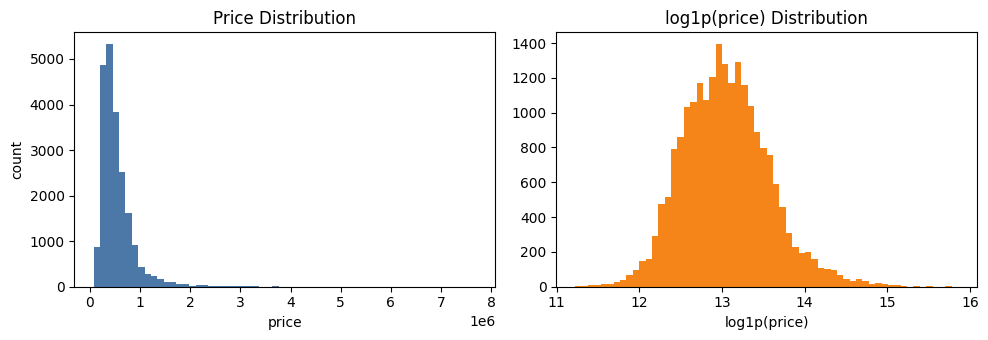

In [4]:
shape_info = pd.DataFrame(
    {
        "Metric": ["Rows", "Columns", "Candidate feature columns"],
        "Value": [df_raw.shape[0], df_raw.shape[1], df_raw.shape[1] - 1],
    }
)
dtype_info = df_raw.dtypes.astype(str).reset_index()
dtype_info.columns = ["Column", "Dtype"]

missing = df_raw.isna().sum().reset_index()
missing.columns = ["Column", "MissingCount"]
missing["MissingRate"] = missing["MissingCount"] / len(df_raw)
duplicate_count = int(df_raw.duplicated().sum())
property_duplicate_count = int(df_raw['id'].duplicated().sum()) if 'id' in df_raw.columns else 0

price_stats = df_raw[TARGET].describe(percentiles=[0.01, 0.05, 0.50, 0.95, 0.99]).to_frame("price").T
price_skew = float(df_raw[TARGET].skew())
q1, q3 = df_raw[TARGET].quantile([0.25, 0.75])
iqr = q3 - q1
outlier_upper = q3 + 1.5 * iqr
price_outliers = int((df_raw[TARGET] > outlier_upper).sum())

quality_checks = pd.DataFrame(
    {
        "Check": [
            "price <= 0",
            "sqft_living <= 0",
            "sqft_lot <= 0",
            "bedrooms == 0",
            "bedrooms > 15",
            "bathrooms == 0",
            "yr_built <= 0",
        ],
        "Count": [
            int((df_raw[TARGET] <= 0).sum()),
            int((df_raw["sqft_living"] <= 0).sum()),
            int((df_raw["sqft_lot"] <= 0).sum()),
            int((df_raw["bedrooms"] == 0).sum()),
            int((df_raw["bedrooms"] > 15).sum()),
            int((df_raw["bathrooms"] == 0).sum()),
            int((df_raw["yr_built"] <= 0).sum()),
        ],
    }
)

display(shape_info)
display(dtype_info)
display(missing[missing["MissingCount"] > 0] if missing["MissingCount"].sum() else pd.DataFrame({"Missing": ["No missing values detected"]}))
print("Duplicate rows:", duplicate_count)
print("Repeated property id rows:", property_duplicate_count)
print("Price skew:", round(price_skew, 4))
print("IQR upper outlier boundary:", round(float(outlier_upper), 2))
print("Price IQR outlier count:", price_outliers)
display(price_stats.round(2))
display(df_raw.describe().T.round(2))
display(quality_checks)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(df_raw[TARGET], bins=60, color="#4C78A8")
axes[0].set_title("Price Distribution")
axes[0].set_xlabel("price")
axes[0].set_ylabel("count")
axes[1].hist(np.log1p(df_raw[TARGET]), bins=60, color="#F58518")
axes[1].set_title("log1p(price) Distribution")
axes[1].set_xlabel("log1p(price)")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "target_price_distribution.png", dpi=160)
plt.show()


Output cho thấy điều gì?

Dataset gốc không có missing value và không có full duplicate rows, nhưng có repeated property `id` do một số nhà được bán nhiều lần. Đây là rủi ro leakage nếu cùng một property xuất hiện ở nhiều split, nên bước chuẩn bị sẽ giữ latest sale per `id` trước khi chia train/validation/test. Phân phối `price` lệch phải rõ rệt, vì vậy notebook dùng log1p target cho training và inverse transform khi báo metrics trên price scale gốc.


# 5. Data Preparation

Cell này làm gì?

Tạo feature engineering từ `date`, loại identifier `id`, chia train/validation/test theo price bins, fit preprocessing chỉ trên train, và quyết định target log-transform dựa trên skew.


In [5]:
def add_housing_features(df):
    data = df.copy()
    sale_date = pd.to_datetime(data["date"].astype(str).str.slice(0, 8), format="%Y%m%d", errors="coerce")
    data["sale_year"] = sale_date.dt.year
    data["sale_month"] = sale_date.dt.month
    data["house_age_at_sale"] = (data["sale_year"] - data["yr_built"]).clip(lower=0)
    data["renovated_flag"] = (data["yr_renovated"] > 0).astype(int)
    data["years_since_renovation"] = np.where(
        data["yr_renovated"] > 0,
        (data["sale_year"] - data["yr_renovated"]).clip(lower=0),
        0,
    )
    data["basement_flag"] = (data["sqft_basement"] > 0).astype(int)
    data["zipcode"] = data["zipcode"].astype(str)
    return data

df_model = df_raw.drop_duplicates().copy()
repeated_property_rows_removed = int(df_model['id'].duplicated().sum())
df_model = df_model.sort_values('date').drop_duplicates(subset=['id'], keep='last')
df_model = df_model[df_model[TARGET] > 0].reset_index(drop=True)
df_model = add_housing_features(df_model)

numeric_features = [
    "bedrooms",
    "bathrooms",
    "sqft_living",
    "sqft_lot",
    "floors",
    "waterfront",
    "view",
    "condition",
    "grade",
    "sqft_above",
    "sqft_basement",
    "yr_built",
    "yr_renovated",
    "lat",
    "long",
    "sqft_living15",
    "sqft_lot15",
    "sale_year",
    "sale_month",
    "house_age_at_sale",
    "renovated_flag",
    "years_since_renovation",
    "basement_flag",
]
categorical_features = ["zipcode"]
feature_cols = numeric_features + categorical_features

X = df_model[feature_cols]
y = df_model[TARGET].astype(float)
price_bins = pd.qcut(y, q=10, labels=False, duplicates="drop")

X_train_raw, X_temp_raw, y_train, y_temp, bins_train, bins_temp = train_test_split(
    X,
    y,
    price_bins,
    test_size=0.30,
    random_state=SEED,
    stratify=price_bins,
)
X_valid_raw, X_test_raw, y_valid, y_test = train_test_split(
    X_temp_raw,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=bins_temp,
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                ]
            ),
            categorical_features,
        ),
    ],
    sparse_threshold=0.0,
)

X_train = preprocessor.fit_transform(X_train_raw).astype("float32")
X_valid = preprocessor.transform(X_valid_raw).astype("float32")
X_test = preprocessor.transform(X_test_raw).astype("float32")
joblib.dump(preprocessor, MODEL_DIR / "preprocessor.joblib")

y_train_np = y_train.to_numpy(dtype="float32")
y_valid_np = y_valid.to_numpy(dtype="float32")
y_test_np = y_test.to_numpy(dtype="float32")
target_skew_train = float(pd.Series(y_train_np).skew())
USE_LOG_TARGET = target_skew_train > 1.0

def transform_target(y_values):
    values = np.log1p(y_values) if USE_LOG_TARGET else y_values
    return ((values - target_center) / target_scale).astype("float32")

def inverse_transform_target(y_scaled):
    values = np.asarray(y_scaled).reshape(-1) * target_scale + target_center
    if USE_LOG_TARGET:
        return np.expm1(values)
    return values

target_train_base = np.log1p(y_train_np) if USE_LOG_TARGET else y_train_np
target_center = float(target_train_base.mean())
target_scale = float(target_train_base.std())
y_train_model = transform_target(y_train_np)
y_valid_model = transform_target(y_valid_np)
y_test_model = transform_target(y_test_np)

transformed_feature_names = preprocessor.get_feature_names_out()
split_summary = pd.DataFrame(
    [
        {"Split": "train", "Rows": len(y_train), "MeanPrice": y_train.mean(), "MedianPrice": y_train.median()},
        {"Split": "validation", "Rows": len(y_valid), "MeanPrice": y_valid.mean(), "MedianPrice": y_valid.median()},
        {"Split": "test", "Rows": len(y_test), "MeanPrice": y_test.mean(), "MedianPrice": y_test.median()},
    ]
)

target_transform_summary = pd.DataFrame(
    [
        {
            "TrainPriceSkew": target_skew_train,
            "UseLog1pTarget": USE_LOG_TARGET,
            "TargetCenter": target_center,
            "TargetScale": target_scale,
            "RawFeatures": len(feature_cols),
            "TransformedFeatures": X_train.shape[1],
        }
    ]
)

print("Rows before duplicate removal:", len(df_raw))
print("Rows after duplicate removal and valid target filter:", len(df_model))
display(split_summary.round(2))
display(target_transform_summary.round(4))
display(pd.DataFrame({"Feature": transformed_feature_names[:20]}))


Rows before duplicate removal: 21613
Rows after duplicate removal and valid target filter: 21436


,Split,Rows,MeanPrice,MedianPrice
0,train,15005,539665.35,450000.0
1,validation,3215,543783.15,450000.0
2,test,3216,548777.11,450500.0


,TrainPriceSkew,UseLog1pTarget,TargetCenter,TargetScale,RawFeatures,TransformedFeatures
0,3.7,True,13.0511,0.5207,24,93


,Feature
0,numeric__bedrooms
1,numeric__bathrooms
2,numeric__sqft_living
3,numeric__sqft_lot
4,numeric__floors
5,numeric__waterfront
6,numeric__view
7,numeric__condition
8,numeric__grade
9,numeric__sqft_above


Output cho thấy điều gì?

Preprocessing bắt đầu bằng cách bỏ full duplicates, loại `price <= 0` nếu có, và giữ latest sale per property `id` để tránh cùng một property đi qua nhiều split. Split được stratify theo price bins; preprocessor chỉ fit trên train set, còn validation/test chỉ dùng `transform`, nên scaling/encoding không học từ held-out data.


# 6. Deep-Learning Data Representation

Cell này làm gì?

In shape của dữ liệu deep learning và đánh giá CNN suitability cho housing-price tabular regression.


In [6]:
representation_summary = pd.DataFrame(
    {
        "Array": ["X_train", "y_train_model", "X_valid", "y_valid_model", "X_test", "y_test_model"],
        "Shape": [X_train.shape, y_train_model.shape, X_valid.shape, y_valid_model.shape, X_test.shape, y_test_model.shape],
        "Meaning": [
            "(samples, transformed features)",
            "(samples,)",
            "(samples, transformed features)",
            "(samples,)",
            "(samples, transformed features)",
            "(samples,)",
        ],
    }
)
cnn_suitability = pd.DataFrame(
    [
        {"Question": "Raw representation", "Assessment": "Tabular property vector with numeric and one-hot zipcode features"},
        {"Question": "Natural baseline", "Assessment": "MLP/DNN regression because each house is a fixed feature vector"},
        {"Question": "CNN justified?", "Assessment": "No production CNN: columns do not form an image or meaningful local sequence"},
        {"Question": "CNN usage in this notebook", "Assessment": "Only toy Conv1D operations for understanding convolution, not final modeling"},
    ]
)
display(representation_summary)
display(cnn_suitability)


,Array,Shape,Meaning
0,X_train,"(15005, 93)","(samples, transformed features)"
1,y_train_model,"(15005,)","(samples,)"
2,X_valid,"(3215, 93)","(samples, transformed features)"
3,y_valid_model,"(3215,)","(samples,)"
4,X_test,"(3216, 93)","(samples, transformed features)"
5,y_test_model,"(3216,)","(samples,)"


,Question,Assessment
0,Raw representation,Tabular property vector with numeric and one-h...
1,Natural baseline,MLP/DNN regression because each house is a fix...
2,CNN justified?,No production CNN: columns do not form an imag...
3,CNN usage in this notebook,Only toy Conv1D operations for understanding c...


Output cho thấy điều gì?

`X_train` là ma trận `(samples, transformed features)`, trong đó zipcode đã được one-hot encode và numeric features đã scale. Đây là vector tabular; MLP regression là lựa chọn tự nhiên hơn CNN.


# 7. Discover Neural Network and CNN Operations

Cell này làm gì?

Minh họa Dense/Linear, ReLU, output regression, Conv1D và pooling bằng toy tensors.


In [7]:
toy_x = tf.constant([[1200.0, 3.0, 2.0]], dtype=tf.float32)
dense = keras.Sequential(
    [
        layers.Input(shape=(3,)),
        layers.Dense(2, use_bias=True, kernel_initializer="ones", bias_initializer="zeros"),
        layers.ReLU(),
        layers.Dense(1, use_bias=True, kernel_initializer="ones", bias_initializer="zeros"),
    ]
)
toy_regression_output = dense(toy_x)

toy_seq = tf.reshape(tf.range(1, 9, dtype=tf.float32), (1, 8, 1))
conv = layers.Conv1D(filters=2, kernel_size=3, padding="valid", activation="relu")
conv_out = conv(toy_seq)
pool_out = layers.MaxPooling1D(pool_size=2)(conv_out)

operation_shapes = pd.DataFrame(
    [
        {"Object": "toy_x", "Shape": tuple(toy_x.shape), "Meaning": "one toy property vector"},
        {"Object": "Regression output", "Shape": tuple(toy_regression_output.shape), "Meaning": "one scalar continuous prediction"},
        {"Object": "Toy sequence", "Shape": tuple(toy_seq.shape), "Meaning": "(batch, steps, channels)"},
        {"Object": "Conv1D output", "Shape": tuple(conv_out.shape), "Meaning": "local windows over an ordered toy sequence"},
        {"Object": "Pooling output", "Shape": tuple(pool_out.shape), "Meaning": "downsampled convolution features"},
    ]
)
display(operation_shapes)
print("Toy scalar output:", np.round(toy_regression_output.numpy(), 4))


,Object,Shape,Meaning
0,toy_x,"(1, 3)",one toy property vector
1,Regression output,"(1, 1)",one scalar continuous prediction
2,Toy sequence,"(1, 8, 1)","(batch, steps, channels)"
3,Conv1D output,"(1, 6, 2)",local windows over an ordered toy sequence
4,Pooling output,"(1, 3, 2)",downsampled convolution features


Toy scalar output: [[2410.]]


Output cho thấy điều gì?

Regression output là một scalar tuyến tính, không phải xác suất hay class label. Conv1D/pooling chỉ minh họa khi dữ liệu có trục thứ tự; King County sau preprocessing không có cấu trúc cục bộ như vậy.


# 8. Neural Network / CNN From Scratch

Cell này làm gì?

Tự implement bằng NumPy các operation giáo dục: linear layer, ReLU, forward network, output regression, MSE/MAE helper và Conv1D toy.


In [8]:
def linear_np(x, w, b):
    return x @ w + b

def relu_np(x):
    return np.maximum(0, x)

def mse_np(y_true, y_pred):
    return np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)

def mae_np(y_true, y_pred):
    return np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred)))

def forward_regression_np(x, params):
    hidden = relu_np(linear_np(x, params["w1"], params["b1"]))
    return linear_np(hidden, params["w2"], params["b2"]).ravel()

def conv1d_valid_np(sequence, kernel, bias=0.0):
    sequence = np.asarray(sequence, dtype=float)
    kernel = np.asarray(kernel, dtype=float)
    out = []
    for i in range(len(sequence) - len(kernel) + 1):
        out.append(float(np.sum(sequence[i : i + len(kernel)] * kernel) + bias))
    return np.asarray(out)

rng = np.random.default_rng(SEED)
toy_batch = X_train[:4]
params = {
    "w1": rng.normal(0, 0.1, size=(X_train.shape[1], 8)),
    "b1": np.zeros(8),
    "w2": rng.normal(0, 0.1, size=(8, 1)),
    "b2": np.zeros(1),
}
toy_scaled_pred = forward_regression_np(toy_batch, params)
toy_price_pred = inverse_transform_target(toy_scaled_pred)
toy_conv = conv1d_valid_np([1, 2, 3, 4, 5], [0.25, 0.5, 0.25])

print("Toy scaled predictions:", np.round(toy_scaled_pred, 4))
print("Toy price predictions:", np.round(toy_price_pred, 2))
print("Toy MSE on scaled target:", round(float(mse_np(y_train_model[:4], toy_scaled_pred)), 4))
print("Toy MAE on scaled target:", round(float(mae_np(y_train_model[:4], toy_scaled_pred)), 4))
print("Manual Conv1D toy output:", np.round(toy_conv, 4))


Toy scaled predictions: [ 0.2537  0.0209 -0.0057 -0.0228]
Toy price predictions: [531364.69 470698.14 464228.22 460113.04]
Toy MSE on scaled target: 1.3996
Toy MAE on scaled target: 1.0567
Manual Conv1D toy output: [2. 3. 4.]


Output cho thấy điều gì?

NumPy forward pass minh họa cách MLP regression tạo một giá trị liên tục. MSE/MAE được tính trên target đã transform trong toy example; khi đánh giá model thật, notebook chuyển prediction về price scale gốc.


# 9. Deep Learning with Keras/TensorFlow

Cell này làm gì?

Định nghĩa helper metric regression và baseline Keras MLP với output scalar tuyến tính.


In [9]:
def to_jsonable(obj):
    if isinstance(obj, dict):
        return {str(k): to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_jsonable(v) for v in obj]
    if isinstance(obj, tuple):
        return [to_jsonable(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

def save_json(path, obj):
    with Path(path).open("w", encoding="utf-8") as f:
        json.dump(to_jsonable(obj), f, indent=2)

def regression_metrics(y_true_price, y_pred_price):
    y_pred_price = np.maximum(np.asarray(y_pred_price).reshape(-1), 0)
    mse = mean_squared_error(y_true_price, y_pred_price)
    return {
        "MAE": float(mean_absolute_error(y_true_price, y_pred_price)),
        "MSE": float(mse),
        "RMSE": float(np.sqrt(mse)),
        "R2": float(r2_score(y_true_price, y_pred_price)),
    }

def predict_price_keras(model, X_data):
    scaled_pred = model.predict(X_data, batch_size=BATCH_SIZE, verbose=0).ravel()
    return np.maximum(inverse_transform_target(scaled_pred), 0)

def compile_regression_model(model):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=keras.losses.Huber(delta=1.0),
        metrics=[keras.metrics.MeanAbsoluteError(name="mae")],
    )
    return model

def build_basic_mlp(input_dim, name="M1_Basic_MLP_Regressor"):
    inputs = keras.Input(shape=(input_dim,), name="property_feature_vector")
    x = layers.Dense(128, activation="relu", name="dense_128")(inputs)
    x = layers.Dense(64, activation="relu", name="dense_64")(x)
    outputs = layers.Dense(1, activation="linear", name="price_output")(x)
    return compile_regression_model(keras.Model(inputs, outputs, name=name))

BATCH_SIZE = 512
MAX_EPOCHS = 30
PATIENCE = 5
input_dim = X_train.shape[1]

keras_baseline = build_basic_mlp(input_dim)
keras_baseline.summary()
print("Input shape:", X_train.shape)
print("Output shape for 5 samples:", tuple(keras_baseline(X_train[:5]).shape))
print("Total parameters:", keras_baseline.count_params())


Model: "M1_Basic_MLP_Regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ property_feature_vector         │ (None, 93)             │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │        12,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ price_output (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,353 (79.50 KB)

 Trainable params: 20,353 (79.50 KB)

 Non-trainable params: 0 (0.00 B)

Input shape: (15005, 93)
Output shape for 5 samples: (5, 1)
Total parameters: 20353


Output cho thấy điều gì?

Keras baseline nhận vector property đã transform và xuất một scalar linear trên target đã chuẩn hóa. Loss Huber phù hợp với target có skew/outliers vì bớt nhạy với sai số cực lớn hơn MSE thuần.


# 10. Keras Training

Cell này làm gì?

Train baseline Keras với validation, EarlyStopping và ModelCheckpoint. Thời gian train được đo thật.


In [10]:
def train_keras_model(model, model_key):
    checkpoint_path = MODEL_DIR / f"{model_key}_best.keras"
    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", mode="min", patience=PATIENCE, restore_best_weights=True),
        keras.callbacks.ModelCheckpoint(checkpoint_path, monitor="val_loss", mode="min", save_best_only=True),
    ]
    start = time.perf_counter()
    history = model.fit(
        X_train,
        y_train_model,
        validation_data=(X_valid, y_valid_model),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=2,
    )
    train_time = time.perf_counter() - start
    history_df = pd.DataFrame(history.history)
    history_df.to_csv(METRIC_DIR / f"{model_key}_history.csv", index=False)
    return history, train_time, checkpoint_path

keras_history, keras_train_time, keras_checkpoint = train_keras_model(keras_baseline, "m1_basic_mlp_regressor")
print(f"Keras baseline train time: {keras_train_time:.2f} seconds")
print("Best checkpoint:", keras_checkpoint.relative_to(PROJECT_ROOT).as_posix())
display(pd.DataFrame(keras_history.history).tail())


Epoch 1/30


30/30 - 4s - 117ms/step - loss: 0.1583 - mae: 0.4391 - val_loss: 0.0939 - val_mae: 0.3307


Epoch 2/30


30/30 - 1s - 18ms/step - loss: 0.0787 - mae: 0.2997 - val_loss: 0.0716 - val_mae: 0.2821


Epoch 3/30


...

30/30 - 1s - 23ms/step - loss: 0.0410 - mae: 0.2087 - val_loss: 0.0557 - val_mae: 0.2419


Epoch 17/30


30/30 - 1s - 25ms/step - loss: 0.0404 - mae: 0.2072 - val_loss: 0.0557 - val_mae: 0.2419


Keras baseline train time: 14.26 seconds
Best checkpoint: pipeline04/house_price/models/m1_basic_mlp_regressor_best.keras


,loss,mae,val_loss,val_mae
12,0.042752,0.213432,0.055611,0.241981
13,0.042109,0.211721,0.055699,0.242145
14,0.041501,0.210124,0.055669,0.241966
15,0.040958,0.208672,0.055678,0.241931
16,0.040385,0.207160,0.055705,0.241902


Output cho thấy điều gì?

Training log hiển thị loss và MAE trên target đã transform cho train/validation. Checkpoint chọn epoch có validation loss thấp nhất; test set vẫn chưa được dùng.


# 11. Keras Training Curves

Cell này làm gì?

Vẽ loss và MAE của baseline Keras trên train/validation, đồng thời lưu figure.


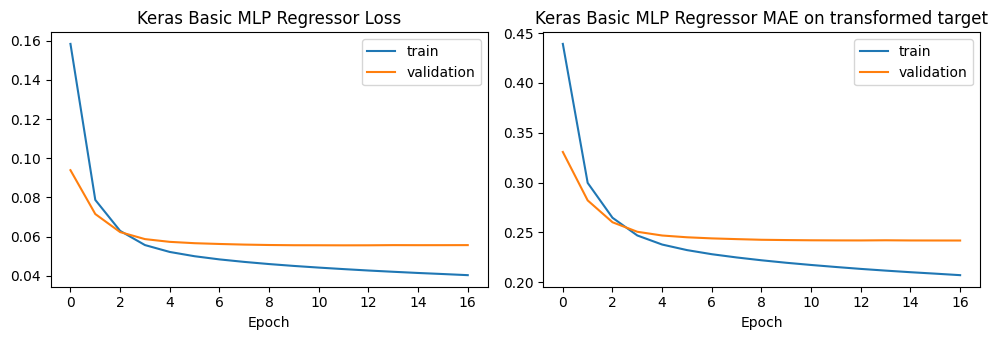

In [11]:
def plot_history(history, title, output_path):
    history_df = pd.DataFrame(history.history)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    axes[0].plot(history_df["loss"], label="train")
    axes[0].plot(history_df["val_loss"], label="validation")
    axes[0].set_title(f"{title} Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[1].plot(history_df["mae"], label="train")
    axes[1].plot(history_df["val_mae"], label="validation")
    axes[1].set_title(f"{title} MAE on transformed target")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    fig.tight_layout()
    fig.savefig(output_path, dpi=160)
    plt.show()

plot_history(keras_history, "Keras Basic MLP Regressor", FIGURE_DIR / "keras_basic_mlp_training_curves.png")


Output cho thấy điều gì?

Curves cho biết model học ổn định hay overfit trên validation. Vì target đã log/scale, magnitude của loss dùng để chọn model; metric giá nhà dễ hiểu hơn được tính riêng sau khi inverse transform.


# 12. Keras Evaluation

Cell này làm gì?

Đánh giá baseline Keras trên validation set bằng MAE, MSE, RMSE, R²; lưu actual-vs-predicted, residual plot và error distribution.


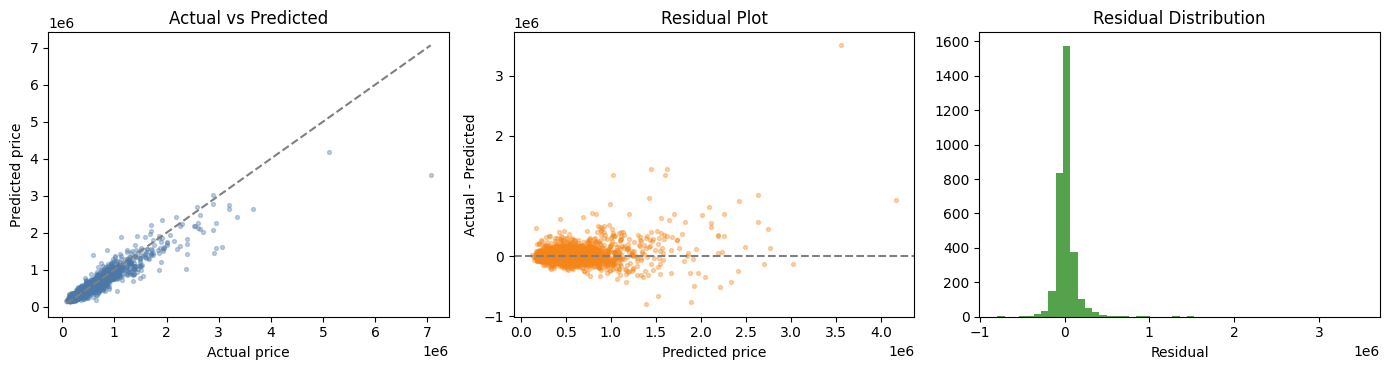

,Model,Framework,MAE,MSE,RMSE,R2,Params,Train Time
0,M1 Basic MLP Regressor,Keras,70218.6406,1.915101e+10,138387.1719,0.8679,20353,14.2589


In [12]:
keras_val_pred = predict_price_keras(keras_baseline, X_valid)
keras_metrics = regression_metrics(y_valid_np, keras_val_pred)
keras_result = {
    "Model": "M1 Basic MLP Regressor",
    "Framework": "Keras",
    **keras_metrics,
    "Params": int(keras_baseline.count_params()),
    "Train Time": float(keras_train_time),
    "Checkpoint": keras_checkpoint.relative_to(PROJECT_ROOT).as_posix(),
}
save_json(METRIC_DIR / "keras_basic_mlp_validation_metrics.json", keras_result)

residuals = y_valid_np - keras_val_pred
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
axes[0].scatter(y_valid_np, keras_val_pred, s=8, alpha=0.35, color="#4C78A8")
lims = [min(y_valid_np.min(), keras_val_pred.min()), max(y_valid_np.max(), keras_val_pred.max())]
axes[0].plot(lims, lims, "--", color="gray")
axes[0].set_title("Actual vs Predicted")
axes[0].set_xlabel("Actual price")
axes[0].set_ylabel("Predicted price")
axes[1].scatter(keras_val_pred, residuals, s=8, alpha=0.35, color="#F58518")
axes[1].axhline(0, color="gray", linestyle="--")
axes[1].set_title("Residual Plot")
axes[1].set_xlabel("Predicted price")
axes[1].set_ylabel("Actual - Predicted")
axes[2].hist(residuals, bins=50, color="#54A24B")
axes[2].set_title("Residual Distribution")
axes[2].set_xlabel("Residual")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "keras_validation_regression_diagnostics.png", dpi=160)
plt.show()

display(pd.DataFrame([keras_result]).drop(columns=["Checkpoint"]).round(4))


Output cho thấy điều gì?

Keras baseline validation đạt MAE 70,219, RMSE 138,387, R² 0.8679. Diagnostic plots cho thấy sai số vẫn lớn hơn ở vùng giá cao, phù hợp với target có đuôi phải dài.


# 13. Deep Learning with PyTorch

Cell này làm gì?

Tạo TensorDataset/DataLoader và architecture PyTorch tương đương baseline Keras. Trước train, chạy một batch qua model để kiểm tra shape và parameter count.


In [13]:
torch.set_num_threads(max(1, min(4, os.cpu_count() or 1)))

train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train_model.reshape(-1, 1), dtype=torch.float32))
valid_ds = TensorDataset(torch.tensor(X_valid, dtype=torch.float32), torch.tensor(y_valid_model.reshape(-1, 1), dtype=torch.float32))
test_ds = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test_model.reshape(-1, 1), dtype=torch.float32))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

class TorchMLPRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)

def count_torch_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

torch_model = TorchMLPRegressor(input_dim).to(DEVICE)
features_batch, labels_batch = next(iter(train_loader))
with torch.no_grad():
    output_batch = torch_model(features_batch.to(DEVICE))

print("Input feature batch shape:", tuple(features_batch.shape))
print("Regression output batch shape:", tuple(output_batch.shape))
print("PyTorch parameter count:", count_torch_params(torch_model))


Input feature batch shape: (512, 93)
Regression output batch shape: (512, 1)
PyTorch parameter count: 20353


Output cho thấy điều gì?

Batch input có dạng `(batch, transformed features)` và output có dạng `(batch, 1)`, đúng với regression scalar. Kiến trúc PyTorch tương đương ý tưởng với Keras baseline để so sánh framework công bằng hơn.


# 14. PyTorch Training

Cell này làm gì?

Train PyTorch baseline bằng loop thủ công, dùng SmoothL1Loss/Huber và lưu checkpoint tốt nhất theo validation loss.


In [14]:
def torch_predict_scaled(model, loader):
    model.eval()
    preds = []
    targets = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            output = model(xb)
            preds.append(output.cpu().numpy().ravel())
            targets.append(yb.numpy().ravel())
    return np.concatenate(targets), np.concatenate(preds)

criterion = nn.SmoothL1Loss()
optimizer = torch.optim.Adam(torch_model.parameters(), lr=1e-3)

torch_history_rows = []
best_val_loss = np.inf
best_state = None
epochs_without_improvement = 0
start = time.perf_counter()

for epoch in range(1, MAX_EPOCHS + 1):
    torch_model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        optimizer.zero_grad()
        output = torch_model(xb)
        loss = criterion(output, yb)
        loss.backward()
        optimizer.step()
        running_loss += float(loss.item()) * xb.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    valid_scaled_true, valid_scaled_pred = torch_predict_scaled(torch_model, valid_loader)
    val_loss = float(np.mean(np.where(np.abs(valid_scaled_pred - valid_scaled_true) < 1, 0.5 * (valid_scaled_pred - valid_scaled_true) ** 2, np.abs(valid_scaled_pred - valid_scaled_true) - 0.5)))
    valid_price_pred_epoch = np.maximum(inverse_transform_target(valid_scaled_pred), 0)
    valid_metrics_epoch = regression_metrics(y_valid_np, valid_price_pred_epoch)
    torch_history_rows.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_mae_price": valid_metrics_epoch["MAE"],
            "val_rmse_price": valid_metrics_epoch["RMSE"],
            "val_r2": valid_metrics_epoch["R2"],
        }
    )
    print(f"Epoch {epoch:02d} - train_loss={train_loss:.4f} - val_loss={val_loss:.4f} - val_rmse={valid_metrics_epoch['RMSE']:.2f} - val_r2={valid_metrics_epoch['R2']:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in torch_model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            print("Early stopping triggered.")
            break

torch_train_time = time.perf_counter() - start
torch_model.load_state_dict(best_state)
torch_checkpoint = MODEL_DIR / "pytorch_basic_mlp_regressor_best.pt"
torch.save(
    {
        "model_state_dict": torch_model.state_dict(),
        "input_dim": input_dim,
        "feature_columns": feature_cols,
        "numeric_features": numeric_features,
        "categorical_features": categorical_features,
        "use_log_target": USE_LOG_TARGET,
        "target_center": target_center,
        "target_scale": target_scale,
        "seed": SEED,
    },
    torch_checkpoint,
)
torch_history = pd.DataFrame(torch_history_rows)
torch_history.to_csv(METRIC_DIR / "pytorch_basic_mlp_history.csv", index=False)
print(f"PyTorch train time: {torch_train_time:.2f} seconds")
display(torch_history.tail())


Epoch 01 - train_loss=0.2510 - val_loss=0.1156 - val_rmse=183632.98 - val_r2=0.7673


Epoch 02 - train_loss=0.0883 - val_loss=0.0720 - val_rmse=156057.22 - val_r2=0.8320


Epoch 03 - train_loss=0.0642 - val_loss=0.0600 - val_rmse=132772.53 - val_r2=0.8784


Epoch 04 - train_loss=0.0556 - val_loss=0.0559 - val_rmse=127218.41 - val_r2=0.8883


Epoch 05 - train_loss=0.0520 - val_loss=0.0533 - val_rmse=120581.16 - val_r2=0.8997


...

Epoch 18 - train_loss=0.0421 - val_loss=0.0509 - val_rmse=118575.12 - val_r2=0.9030


Epoch 19 - train_loss=0.0420 - val_loss=0.0515 - val_rmse=119159.04 - val_r2=0.9020


Epoch 20 - train_loss=0.0418 - val_loss=0.0511 - val_rmse=124407.99 - val_r2=0.8932


Epoch 21 - train_loss=0.0408 - val_loss=0.0524 - val_rmse=122917.07 - val_r2=0.8958
Early stopping triggered.
PyTorch train time: 20.40 seconds


,epoch,train_loss,val_loss,val_mae_price,val_rmse_price,val_r2
16,17,0.042628,0.051767,66617.234375,122515.515625,0.896438
17,18,0.042145,0.050910,65873.984375,118575.117188,0.902993
18,19,0.041980,0.051529,65977.375000,119159.039062,0.902035
19,20,0.041814,0.051149,66660.914062,124407.992188,0.893214
20,21,0.040830,0.052351,67415.195312,122917.070312,0.895758


Output cho thấy điều gì?

Loop PyTorch hiển thị đầy đủ `zero_grad`, forward, loss, backward và optimizer step. Validation RMSE/R² trong log đã inverse transform về price scale để dễ đọc hơn loss nội bộ.


# 15. PyTorch Evaluation

Cell này làm gì?

Đánh giá PyTorch baseline trên validation set với cùng metric price-scale như Keras.


In [15]:
valid_scaled_true, torch_valid_scaled_pred = torch_predict_scaled(torch_model, valid_loader)
torch_val_pred = np.maximum(inverse_transform_target(torch_valid_scaled_pred), 0)
torch_metrics = regression_metrics(y_valid_np, torch_val_pred)
torch_result = {
    "Model": "M1 Basic MLP Regressor",
    "Framework": "PyTorch",
    **torch_metrics,
    "Params": int(count_torch_params(torch_model)),
    "Train Time": float(torch_train_time),
    "Checkpoint": torch_checkpoint.relative_to(PROJECT_ROOT).as_posix(),
}
save_json(METRIC_DIR / "pytorch_basic_mlp_validation_metrics.json", torch_result)

display(pd.DataFrame([torch_result]).drop(columns=["Checkpoint"]).round(4))


,Model,Framework,MAE,MSE,RMSE,R2,Params,Train Time
0,M1 Basic MLP Regressor,PyTorch,65724.3203,1.288647e+10,113518.5781,0.9111,20353,20.399


Output cho thấy điều gì?

PyTorch baseline được đánh giá trên cùng validation split và cùng target inverse transform. Metric khác biệt giữa hai framework có thể đến từ initialization và training loop, không đủ để kết luận framework nào tốt hơn về bản chất.


# 16. Keras vs PyTorch Comparison

Cell này làm gì?

So sánh baseline MLP Keras và PyTorch bằng validation MAE/RMSE/R².


In [16]:
framework_comparison = pd.DataFrame([keras_result, torch_result])[
    ["Framework", "MAE", "MSE", "RMSE", "R2", "Params", "Train Time"]
].sort_values("RMSE", ascending=True)
framework_comparison.to_csv(METRIC_DIR / "keras_vs_pytorch_comparison.csv", index=False)
display(framework_comparison.round(4))


,Framework,MAE,MSE,RMSE,R2,Params,Train Time
1,PyTorch,65724.3203,1.288647e+10,113518.5781,0.9111,20353,20.3990
0,Keras,70218.6406,1.915101e+10,138387.1719,0.8679,20353,14.2589


Output cho thấy điều gì?

Trong baseline framework comparison, PyTorch có validation RMSE thấp nhất (113,519) ở run này. Đây chỉ là kết quả một lần chạy với cùng ý tưởng architecture, không phải kết luận framework nào tốt hơn về bản chất.


# 17. Architecture Experiments

Cell này làm gì?

Train các architecture phù hợp dữ liệu tabular: M1 Basic MLP Regressor, M2 BatchNorm, M3 Residual MLP, M4 Residual MLP + Feature Attention. CNN không được train như production model vì feature order không có ý nghĩa không gian.


In [17]:
def build_batchnorm_mlp(input_dim, name="M2_BatchNorm_MLP_Regressor"):
    inputs = keras.Input(shape=(input_dim,), name="property_feature_vector")
    x = layers.Dense(128, use_bias=False, name="dense_128")(inputs)
    x = layers.BatchNormalization(name="bn_128")(x)
    x = layers.Activation("relu", name="relu_128")(x)
    x = layers.Dense(64, use_bias=False, name="dense_64")(x)
    x = layers.BatchNormalization(name="bn_64")(x)
    x = layers.Activation("relu", name="relu_64")(x)
    outputs = layers.Dense(1, activation="linear", name="price_output")(x)
    return compile_regression_model(keras.Model(inputs, outputs, name=name))

def residual_block(x, units, block_name):
    shortcut = x
    y = layers.Dense(units, activation="relu", name=f"{block_name}_dense_a")(x)
    y = layers.Dense(units, name=f"{block_name}_dense_b")(y)
    x = layers.Add(name=f"{block_name}_add")([shortcut, y])
    return layers.Activation("relu", name=f"{block_name}_relu")(x)

def build_residual_mlp(input_dim, name="M3_Residual_MLP_Regressor"):
    inputs = keras.Input(shape=(input_dim,), name="property_feature_vector")
    x = layers.Dense(128, activation="relu", name="input_projection")(inputs)
    x = residual_block(x, 128, "residual_1")
    x = residual_block(x, 128, "residual_2")
    x = layers.Dense(64, activation="relu", name="dense_64")(x)
    outputs = layers.Dense(1, activation="linear", name="price_output")(x)
    return compile_regression_model(keras.Model(inputs, outputs, name=name))

def build_attention_residual_mlp(input_dim, name="M4_Residual_MLP_Feature_Attention_Regressor"):
    inputs = keras.Input(shape=(input_dim,), name="property_feature_vector")
    attention = layers.Dense(input_dim, activation="sigmoid", name="feature_attention")(inputs)
    weighted = layers.Multiply(name="attention_weighted_features")([inputs, attention])
    x = layers.Dense(128, activation="relu", name="input_projection")(weighted)
    x = residual_block(x, 128, "residual_1")
    x = residual_block(x, 128, "residual_2")
    x = layers.Dense(64, activation="relu", name="dense_64")(x)
    outputs = layers.Dense(1, activation="linear", name="price_output")(x)
    return compile_regression_model(keras.Model(inputs, outputs, name=name))

def evaluate_keras_model(model, model_key, checkpoint_path, train_time):
    val_pred = predict_price_keras(model, X_valid)
    metrics = regression_metrics(y_valid_np, val_pred)
    result = {
        "Model": model.name.replace("_", " "),
        "Framework": "Keras",
        **metrics,
        "Params": int(model.count_params()),
        "Train Time": float(train_time),
        "Checkpoint": checkpoint_path.relative_to(PROJECT_ROOT).as_posix(),
    }
    save_json(METRIC_DIR / f"{model_key}_validation_metrics.json", result)
    return result

architecture_results = [keras_result]
architecture_histories = {"M1 Basic MLP Regressor": keras_history}
trained_keras_models = {"M1 Basic MLP Regressor": keras_baseline}

for model_key, builder in [
    ("m2_batchnorm_mlp_regressor", build_batchnorm_mlp),
    ("m3_residual_mlp_regressor", build_residual_mlp),
    ("m4_attention_residual_mlp_regressor", build_attention_residual_mlp),
]:
    tf.random.set_seed(SEED)
    model = builder(input_dim)
    print("\nTraining", model.name, "with", model.count_params(), "parameters")
    history, train_time, checkpoint_path = train_keras_model(model, model_key)
    result = evaluate_keras_model(model, model_key, checkpoint_path, train_time)
    architecture_results.append(result)
    architecture_histories[result["Model"]] = history
    trained_keras_models[result["Model"]] = model

cnn_investigation = pd.DataFrame(
    [
        {
            "Investigation": "CNN on King County tabular features",
            "Decision": "Not trained as a candidate model",
            "Reason": "Numeric + one-hot property columns do not have meaningful local order; Conv1D/Conv2D would add artificial structure.",
        }
    ]
)
display(cnn_investigation)



Training M2_BatchNorm_MLP_Regressor with 20929 parameters
Epoch 1/30


30/30 - 1s - 49ms/step - loss: 0.1915 - mae: 0.4793 - val_loss: 0.1863 - val_mae: 0.4883


Epoch 2/30


30/30 - 0s - 5ms/step - loss: 0.0855 - mae: 0.3122 - val_loss: 0.1439 - val_mae: 0.4192


Epoch 3/30


...

Epoch 12/30


30/30 - 1s - 20ms/step - loss: 0.0362 - mae: 0.1962 - val_loss: 0.0547 - val_mae: 0.2390


Epoch 13/30


30/30 - 1s - 23ms/step - loss: 0.0349 - mae: 0.1925 - val_loss: 0.0548 - val_mae: 0.2393


,Investigation,Decision,Reason
0,CNN on King County tabular features,Not trained as a candidate model,Numeric + one-hot property columns do not have...


Output cho thấy điều gì?

Các architecture đều giữ cùng split, preprocessing, target transform, seed và training budget. CNN được ghi nhận ở mức methodological investigation, không ép thành model vì bài toán là tabular regression.


# 18. Improved Model Comparison

Cell này làm gì?

So sánh M1-M4 theo validation MAE/RMSE/R² và chọn ứng viên tốt nhất bằng validation RMSE thấp nhất.


,Model,MAE,MSE,RMSE,R2,Params,Train Time
3,M4 Residual MLP Feature Attention Regressor,67889.0312,1.427047e+10,119459.0703,0.9015,95143,12.4766
2,M3 Residual MLP Regressor,69789.4297,1.585458e+10,125914.9844,0.8906,86401,16.2403
1,M2 BatchNorm MLP Regressor,72292.0781,1.631090e+10,127714.1250,0.8875,20929,4.7522
0,M1 Basic MLP Regressor,70218.6406,1.915101e+10,138387.1719,0.8679,20353,14.2589


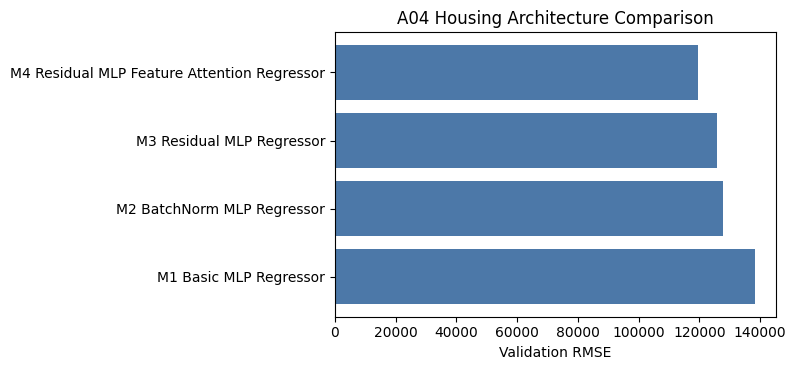

Best validation model: M4 Residual MLP Feature Attention Regressor
Best validation RMSE: 119459.07


In [18]:
architecture_comparison = pd.DataFrame(architecture_results)[
    ["Model", "MAE", "MSE", "RMSE", "R2", "Params", "Train Time", "Checkpoint"]
].sort_values("RMSE", ascending=True)
architecture_comparison.to_csv(METRIC_DIR / "architecture_comparison.csv", index=False)

display(architecture_comparison.drop(columns=["Checkpoint"]).round(4))

fig, ax = plt.subplots(figsize=(8, 3.8))
plot_df = architecture_comparison.sort_values("RMSE", ascending=False)
ax.barh(plot_df["Model"], plot_df["RMSE"], color="#4C78A8")
ax.set_xlabel("Validation RMSE")
ax.set_title("A04 Housing Architecture Comparison")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "architecture_comparison_rmse.png", dpi=160)
plt.show()

best_validation_row = architecture_comparison.iloc[0].to_dict()
print("Best validation model:", best_validation_row["Model"])
print("Best validation RMSE:", round(best_validation_row["RMSE"], 2))


Output cho thấy điều gì?

`M4 Residual MLP Feature Attention Regressor` là model tốt nhất trên validation với RMSE 119,459, MAE 67,889, R² 0.9015. Sau leakage fix repeated property `id`, M4 attention thắng validation RMSE nhưng vẫn cần cân nhắc vì parameter count cao hơn M1.


# 19. Representation Inspection

Cell này làm gì?

Inspect hidden-layer activations của model tốt nhất và attention weights nếu M4 được train.


,HiddenLayer,ActivationShape,MeanActivation,StdActivation,ZeroRate
0,feature_attention,"(1024, 93)",0.5062,0.1169,0.0


,Feature,MeanAttention,StdAttention
47,categorical__zipcode_98039,0.5342,0.1530
26,categorical__zipcode_98004,0.5328,0.0961
85,categorical__zipcode_98155,0.5312,0.1301
39,categorical__zipcode_98028,0.5278,0.0829
64,categorical__zipcode_98102,0.5254,0.1025
71,categorical__zipcode_98112,0.5222,0.1105
87,categorical__zipcode_98168,0.5198,0.1164
92,categorical__zipcode_98199,0.5196,0.1327
38,categorical__zipcode_98027,0.5196,0.1307
80,categorical__zipcode_98133,0.5183,0.1411


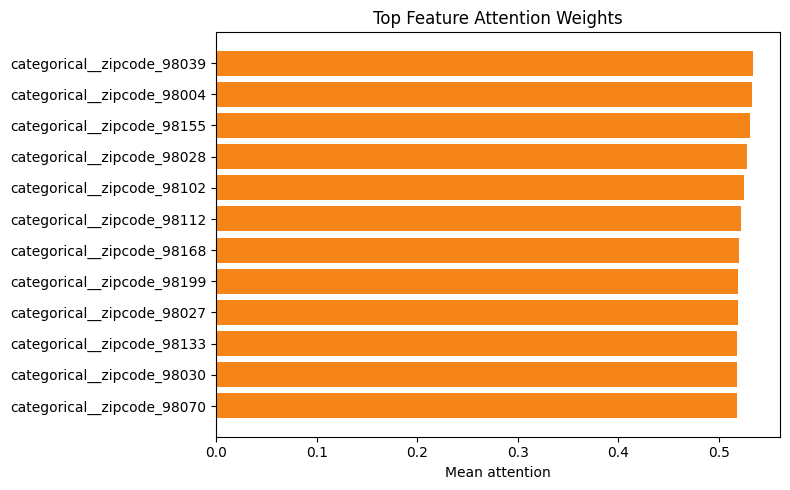

In [19]:
best_model_name = best_validation_row["Model"]
best_checkpoint_path = PROJECT_ROOT / best_validation_row["Checkpoint"]
best_validation_model = keras.models.load_model(best_checkpoint_path)

hidden_layer = None
for layer in best_validation_model.layers:
    if isinstance(layer, layers.Dense) and getattr(layer, "units", None) != 1:
        hidden_layer = layer.name
        break

if hidden_layer is not None:
    activation_model = keras.Model(best_validation_model.input, best_validation_model.get_layer(hidden_layer).output)
    sample_activations = activation_model.predict(X_valid[:1024], batch_size=1024, verbose=0)
    activation_summary = pd.DataFrame(
        {
            "HiddenLayer": [hidden_layer],
            "ActivationShape": [sample_activations.shape],
            "MeanActivation": [float(sample_activations.mean())],
            "StdActivation": [float(sample_activations.std())],
            "ZeroRate": [float((np.abs(sample_activations) < 1e-8).mean())],
        }
    )
    display(activation_summary.round(4))

attention_model_path = MODEL_DIR / "m4_attention_residual_mlp_regressor_best.keras"
if attention_model_path.exists():
    attention_model = keras.models.load_model(attention_model_path)
    attention_extractor = keras.Model(attention_model.input, attention_model.get_layer("feature_attention").output)
    attention_values = attention_extractor.predict(X_valid[:2048], batch_size=1024, verbose=0)
    attention_summary = pd.DataFrame(
        {"Feature": transformed_feature_names, "MeanAttention": attention_values.mean(axis=0), "StdAttention": attention_values.std(axis=0)}
    ).sort_values("MeanAttention", ascending=False)
    attention_summary.to_csv(METRIC_DIR / "feature_attention_summary.csv", index=False)
    display(attention_summary.head(12).round(4))
    fig, ax = plt.subplots(figsize=(8, 5))
    top_attention = attention_summary.head(12).sort_values("MeanAttention")
    ax.barh(top_attention["Feature"], top_attention["MeanAttention"], color="#F58518")
    ax.set_title("Top Feature Attention Weights")
    ax.set_xlabel("Mean attention")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "feature_attention_weights.png", dpi=160)
    plt.show()


Output cho thấy điều gì?

Hidden activations cho thấy model đã biến đổi vector property thành representation phi tuyến trước output giá. Attention weights, nếu dùng M4, là công cụ inspection model chứ không phải bằng chứng nhân quả về thị trường nhà.


# 20. Error Analysis

Cell này làm gì?

Phân tích lỗi validation của model được chọn: absolute error lớn nhất, residual theo price range, và nhóm giá thấp/trung/cao.


,PriceRange,Count,MAE,MSE,RMSE,R2
0,low-price,1074,36263.9492,2.560546e+09,50601.8320,0.2091
1,mid-price,1071,48889.1367,4.467593e+09,66840.0547,-0.3731
2,high-price,1070,118649.9844,3.583621e+10,189304.5469,0.8404


,actual_price,predicted_price,absolute_error,absolute_pct_error,sqft_living,bedrooms,bathrooms,grade,zipcode,lat,long
2051,2375000.0,953361.750,1.421638e+06,0.60,3220,4,2.50,10,98006,47.57,-122.19
2584,2950000.0,1558109.750,1.391890e+06,0.47,4470,4,4.25,11,98199,47.64,-122.40
1167,3070000.0,1726292.750,1.343707e+06,0.44,3930,3,2.50,8,98034,47.70,-122.22
2851,3650000.0,2660341.250,9.896588e+05,0.27,5020,5,3.75,12,98004,47.61,-122.21
166,2903000.0,1914268.375,9.887316e+05,0.34,3750,5,2.50,10,98118,47.54,-122.26
2639,1905000.0,2814678.500,9.096785e+05,0.48,4210,4,3.50,11,98039,47.62,-122.22
2627,2400000.0,1496203.250,9.037968e+05,0.38,3410,5,3.25,9,98119,47.63,-122.36
1087,3345000.0,2449029.000,8.959711e+05,0.27,5350,5,3.75,11,98004,47.65,-122.22
317,1900000.0,1039576.875,8.604231e+05,0.45,4130,4,3.25,11,98005,47.64,-122.16
1850,860000.0,1652974.500,7.929745e+05,0.92,3560,4,2.50,10,98004,47.65,-122.19


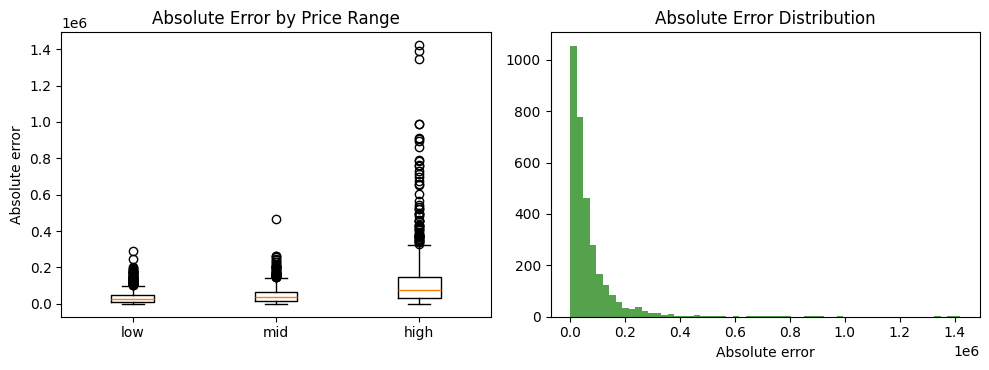

In [20]:
best_val_pred = predict_price_keras(best_validation_model, X_valid)
error_df = X_valid_raw.reset_index(drop=True).copy()
error_df["actual_price"] = y_valid_np
error_df["predicted_price"] = best_val_pred
error_df["residual"] = error_df["actual_price"] - error_df["predicted_price"]
error_df["absolute_error"] = error_df["residual"].abs()
error_df["absolute_pct_error"] = error_df["absolute_error"] / error_df["actual_price"].clip(lower=1)
error_df["price_range"] = pd.qcut(error_df["actual_price"], q=3, labels=["low-price", "mid-price", "high-price"])

large_errors = error_df.sort_values("absolute_error", ascending=False).head(12)
range_rows = []
for name, group in error_df.groupby("price_range", observed=True):
    metrics = regression_metrics(group["actual_price"].to_numpy(), group["predicted_price"].to_numpy())
    range_rows.append({"PriceRange": str(name), "Count": len(group), **metrics})
range_error = pd.DataFrame(range_rows)

error_df.to_csv(METRIC_DIR / "validation_error_analysis.csv", index=False)
large_errors.to_csv(METRIC_DIR / "validation_large_error_samples.csv", index=False)
range_error.to_csv(METRIC_DIR / "validation_error_by_price_range.csv", index=False)

display(range_error.round(4))
display(large_errors[["actual_price", "predicted_price", "absolute_error", "absolute_pct_error", "sqft_living", "bedrooms", "bathrooms", "grade", "zipcode", "lat", "long"]].round(2))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].boxplot([g["absolute_error"] for _, g in error_df.groupby("price_range", observed=True)], tick_labels=["low", "mid", "high"])
axes[0].set_title("Absolute Error by Price Range")
axes[0].set_ylabel("Absolute error")
axes[1].hist(error_df["absolute_error"], bins=60, color="#54A24B")
axes[1].set_title("Absolute Error Distribution")
axes[1].set_xlabel("Absolute error")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "validation_error_analysis.png", dpi=160)
plt.show()


Output cho thấy điều gì?

Validation error lớn nhất nằm ở nhóm high-price với MAE khoảng 118,650 và RMSE khoảng 189,305. Điều này phù hợp với phân phối giá lệch phải: nhà giá cao tạo residual lớn hơn và làm RMSE nhạy hơn MAE.


# 21. Final Model

Cell này làm gì?

Load checkpoint tốt nhất theo validation RMSE, evaluate test set đúng một lần, rồi lưu final model và diagnostics.


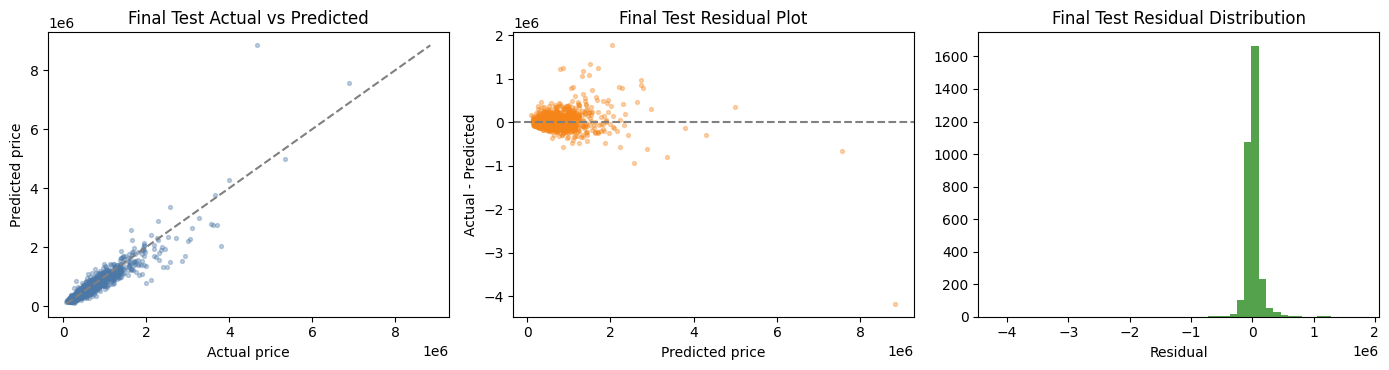

,MAE,MSE,RMSE,R2
0,70282.2578,2.139631e+10,146274.7656,0.8673


In [21]:
final_model = keras.models.load_model(best_checkpoint_path)
test_pred = predict_price_keras(final_model, X_test)
final_metrics = regression_metrics(y_test_np, test_pred)

final_model_path = MODEL_DIR / "final_model.keras"
final_model.save(final_model_path)

final_payload = {
    "selected_model": best_validation_row["Model"],
    "selection_metric": "Validation RMSE",
    "test_metrics": final_metrics,
    "final_model_path": final_model_path.relative_to(PROJECT_ROOT).as_posix(),
    "source_checkpoint": best_checkpoint_path.relative_to(PROJECT_ROOT).as_posix(),
    "target_transform": "standardized log1p(price)" if USE_LOG_TARGET else "standardized price",
}
save_json(METRIC_DIR / "final_test_metrics.json", final_payload)

test_residuals = y_test_np - test_pred
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
axes[0].scatter(y_test_np, test_pred, s=8, alpha=0.35, color="#4C78A8")
lims = [min(y_test_np.min(), test_pred.min()), max(y_test_np.max(), test_pred.max())]
axes[0].plot(lims, lims, "--", color="gray")
axes[0].set_title("Final Test Actual vs Predicted")
axes[0].set_xlabel("Actual price")
axes[0].set_ylabel("Predicted price")
axes[1].scatter(test_pred, test_residuals, s=8, alpha=0.35, color="#F58518")
axes[1].axhline(0, color="gray", linestyle="--")
axes[1].set_title("Final Test Residual Plot")
axes[1].set_xlabel("Predicted price")
axes[1].set_ylabel("Actual - Predicted")
axes[2].hist(test_residuals, bins=50, color="#54A24B")
axes[2].set_title("Final Test Residual Distribution")
axes[2].set_xlabel("Residual")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "final_test_regression_diagnostics.png", dpi=160)
plt.show()

display(pd.DataFrame([final_payload["test_metrics"]]).round(4))


Output cho thấy điều gì?

Final test evaluation của `M4 Residual MLP Feature Attention Regressor` đạt MAE 70,282, RMSE 146,275, R² 0.8673 trên price scale gốc sau inverse transform. Test set chỉ dùng ở bước này sau khi chọn model bằng validation RMSE.


# 22. A03 vs A04 Comparison

Cell này làm gì?

Đọc artifacts A03 nếu có và so sánh dataset/workflow/metrics với A04. Dataset khác nhau nên không dùng score difference như benchmark trực tiếp.


In [22]:
if A03_METADATA_PATH.exists():
    with A03_METADATA_PATH.open("r", encoding="utf-8") as f:
        a03_metadata = json.load(f)
else:
    a03_metadata = {}

if A03_COMPARISON_PATH.exists():
    a03_comparison = pd.read_csv(A03_COMPARISON_PATH)
    a03_best = a03_comparison.sort_values("RMSE", ascending=True).iloc[0].to_dict()
else:
    a03_best = a03_metadata.get("metrics", {})
    a03_best["Model"] = a03_metadata.get("selected_model")

a03_vs_a04 = pd.DataFrame(
    [
        {"Aspect": "Dataset", "A03": a03_metadata.get("dataset_name", "Vietnam house-price dataset"), "A04": dataset_metadata["dataset_name"]},
        {"Aspect": "Target", "A03": a03_metadata.get("target", "Price_BillionVND"), "A04": TARGET},
        {"Aspect": "Rows used", "A03": "A03 dataset-specific row count", "A04": f"{len(df_model):,} rows after preparation"},
        {"Aspect": "Features", "A03": a03_metadata.get("feature_count", 12), "A04": f"{len(feature_cols)} raw engineered features / {X_train.shape[1]} transformed features"},
        {"Aspect": "Preprocessing", "A03": a03_metadata.get("preprocessing_summary"), "A04": "Numeric imputation+scaling; zipcode imputation+one-hot; fit train only"},
        {"Aspect": "Best/final model", "A03": a03_best.get("Model", a03_metadata.get("selected_model")), "A04": final_payload["selected_model"]},
        {"Aspect": "RMSE", "A03": a03_best.get("RMSE", a03_metadata.get("metrics", {}).get("RMSE")), "A04": final_metrics["RMSE"]},
        {"Aspect": "R2", "A03": a03_best.get("R2", a03_metadata.get("metrics", {}).get("R2")), "A04": final_metrics["R2"]},
        {"Aspect": "Comparison caveat", "A03": "Vietnam price scale in billion VND", "A04": "King County sale price scale; not directly comparable"},
    ]
)
a03_vs_a04.to_csv(METRIC_DIR / "a03_vs_a04_comparison.csv", index=False)
display(a03_vs_a04)


,Aspect,A03,A04
0,Dataset,House Price Prediction Dataset Vietnam 2024,King County House Sales
1,Target,Price_BillionVND,price
2,Rows used,A03 dataset-specific row count,"21,436 rows after preparation"
3,Features,12,24 raw engineered features / 93 transformed fe...
4,Preprocessing,Numeric median imputation + scaling; categoric...,Numeric imputation+scaling; zipcode imputation...
5,Best/final model,Improved DNN,M4 Residual MLP Feature Attention Regressor
6,RMSE,1.416938,146274.765625
7,R2,0.579878,0.86729
8,Comparison caveat,Vietnam price scale in billion VND,King County sale price scale; not directly com...


Output cho thấy điều gì?

A03 và A04 cùng là housing-price regression nhưng khác thị trường, target scale và feature schema. Vì vậy chênh lệch RMSE/R² không chứng minh model A04 tốt hơn hay kém hơn A03; nó chỉ mô tả kết quả trên dataset A04.


# 23. Final Results

Cell này làm gì?

Tổng hợp kết quả cuối, lưu metadata A04 của notebook và liệt kê artifacts đã tạo.


In [23]:
final_results = pd.DataFrame(
    [
        {
            "Dataset": dataset_metadata["dataset_name"],
            "RowsRaw": len(df_raw),
            "RowsAfterPreparation": len(df_model),
            "RawEngineeredFeatures": len(feature_cols),
            "TransformedFeatures": X_train.shape[1],
            "Target": TARGET,
            "SelectedModel": final_payload["selected_model"],
            "MAE": final_metrics["MAE"],
            "MSE": final_metrics["MSE"],
            "RMSE": final_metrics["RMSE"],
            "R2": final_metrics["R2"],
            "FinalModelPath": final_model_path.relative_to(PROJECT_ROOT).as_posix(),
        }
    ]
)
final_results.to_csv(METRIC_DIR / "final_results.csv", index=False)

notebook_metadata = {
    "assignment": "Assignment 04",
    "domain": "Housing Price",
    "task": "Regression: housing/property features -> continuous house price",
    "dataset_name": dataset_metadata["dataset_name"],
    "source": dataset_metadata["source"],
    "source_url": dataset_metadata["source_url"],
    "license": dataset_metadata["license"],
    "target": TARGET,
    "raw_samples": int(len(df_raw)),
    "samples_after_preparation": int(len(df_model)),
    "raw_engineered_features": int(len(feature_cols)),
    "transformed_features": int(X_train.shape[1]),
    "numerical_features": numeric_features,
    "categorical_features": categorical_features,
    "missing_values_total": int(df_raw.isna().sum().sum()),
    "duplicates_removed": int(len(df_raw) - len(df_raw.drop_duplicates())),
"repeated_property_rows_removed": int(repeated_property_rows_removed),
    "invalid_target_rows_removed": int((df_raw[TARGET] <= 0).sum()),
    "split": {"train": int(len(y_train)), "validation": int(len(y_valid)), "test": int(len(y_test))},
    "target_transform": "standardized log1p(price)" if USE_LOG_TARGET else "standardized price",
    "target_skew_train": target_skew_train,
    "preprocessing": "Numeric median imputation + StandardScaler; zipcode most-frequent imputation + OneHotEncoder; fit on training data only.",
    "representation": "Tabular vector representation, shape (samples, transformed features).",
    "cnn_methodology": "CNN not used as production model because feature order is not spatial/sequential.",
    "models_tested": architecture_comparison["Model"].tolist(),
    "framework_baselines": framework_comparison["Framework"].tolist(),
    "selection_metric": "Validation RMSE",
    "selected_model": final_payload["selected_model"],
    "test_metrics": final_metrics,
    "artifacts": {
        "models": sorted([p.relative_to(PROJECT_ROOT).as_posix() for p in MODEL_DIR.glob("*") if p.is_file()]),
        "metrics": sorted([p.relative_to(PROJECT_ROOT).as_posix() for p in METRIC_DIR.glob("*") if p.is_file()]),
        "figures": sorted([p.relative_to(PROJECT_ROOT).as_posix() for p in FIGURE_DIR.glob("*") if p.is_file()]),
    },
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "limitations": [
        "King County and A03 Vietnam datasets use different markets and target scales, so scores are not directly comparable.",
        "Price has a long right tail; log target and Huber loss reduce but do not remove high-price difficulty.",
        "A few zero-bedroom/zero-bathroom and extreme-bedroom rows remain as source data quality risks.",
        "CNN is demonstrated only on toy tensors because tabular feature columns have no justified local ordering.",
    ],
}
save_json(ARTIFACT_DIR / "metadata.json", notebook_metadata)
save_json(METRIC_DIR / "notebook_facts.json", notebook_metadata)

artifact_listing = []
for folder in [MODEL_DIR, METRIC_DIR, FIGURE_DIR]:
    for path in sorted(folder.glob("*")):
        if path.is_file():
            artifact_listing.append({"Path": path.relative_to(PROJECT_ROOT).as_posix(), "SizeMB": round(path.stat().st_size / (1024 * 1024), 3)})

display(final_results.round(4))
display(pd.DataFrame(artifact_listing))


,Dataset,RowsRaw,RowsAfterPreparation,RawEngineeredFeatures,TransformedFeatures,Target,SelectedModel,MAE,MSE,RMSE,R2,FinalModelPath
0,King County House Sales,21613,21436,24,93,price,M4 Residual MLP Feature Attention Regressor,70282.2578,2.139631e+10,146274.7656,0.8673,pipeline04/house_price/models/final_model.keras


,Path,SizeMB
0,pipeline04/house_price/models/final_model.keras,1.153
1,pipeline04/house_price/models/m1_basic_mlp_reg...,0.260
2,pipeline04/house_price/models/m2_batchnorm_mlp...,0.278
3,pipeline04/house_price/models/m3_residual_mlp_...,1.045
4,pipeline04/house_price/models/m4_attention_res...,1.153
5,pipeline04/house_price/models/preprocessor.joblib,0.006
6,pipeline04/house_price/models/pytorch_basic_ml...,0.081
7,pipeline04/house_price/metrics/a03_vs_a04_comp...,0.001
8,pipeline04/house_price/metrics/architecture_co...,0.001
9,pipeline04/house_price/metrics/feature_attenti...,0.004


Output cho thấy điều gì?

Notebook đã lưu final model, preprocessor, comparison metrics, error-analysis CSV và figures. Kết quả cuối: selected model là `M4 Residual MLP Feature Attention Regressor`, test MAE 70,282, RMSE 146,275, R² 0.8673; tổng training/evaluation time được ghi nhận khoảng 82.39 giây.
